# Open Street Map Data

This notebook is used to extract hiking route data from the Overpass API ([Link](https://overpass-turbo.eu/)).

First, we request hiking routes from the API using Overpass QL (short for "Overpass Query Language").
In OpenStreetMap, hiking routes are defined as relations. We search for relations with specific signage and the tags "hiking routes," "local walking network",
within an area slightly larger than Switzerland. Using "Center" as Output, OpenStreetMap calculates the central location of each route.
Since the "name" tag is often missing, we interpolate the name by concatenating the start and end points of each hiking route.
Finally, we retrieve the ID, name, latitude, and longitude as data points. 

The data is then converted into a DataFrame object, and a table is created in an SQL database (hosted on Microsoft Azure).

In [ ]:
# Import required libraries
import os
import json
import overpy
import pyodbc
import urllib
import pymssql
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import Integer, String, Float, DATETIME, create_engine

### Connect to API

In [36]:
# Initialize the Overpass API with a custom URL
api = overpy.Overpass(url="http://overpass.osm.ch/api/interpreter")

# Overpass query for hiking trails within Switzerland. Using 'center', we obtain the coordinates in the middle of a hiking trail
query = """
[out:json];
relation
["route"="hiking"]
["network"="lwn"]
["osmc:symbol"~"yellow::yellow_diamond|red:white:red_bar|yellow:white:yellow_diamond|blue:white:blue_bar"]
(45.8899, 6.0872, 47.8085, 10.4921);
out center tags;
"""

# Execute the request
result = api.query(query)

### Save Data to DataFrame

In [38]:
# Add time and datestamp of API call to dataframe
timestamp_apicall = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

# List to store the extracted information
list = []

# Iterate over all relations
for relation in result.relations:

    # Extract relevant data
    name = relation.tags.get('name')
    von = relation.tags.get('from')
    bis = relation.tags.get('to')
    symbol = relation.tags.get('osmc:symbol')
    lat = getattr(relation, 'center_lat')
    lon = getattr(relation, 'center_lon')

    beschreibung = relation.tags.get('description')
    network = relation.tags.get('network')
    operator = relation.tags.get('operator')
    roundtrip = relation.tags.get('roundtrip')
    symbol = relation.tags.get('osmc:symbol')
    type = relation.tags.get('type')
    
    dict = {    
    'id': relation.id,
    'name': name,
    'symbol': symbol,
    'von': von,
    'bis': bis,
    'lat': lat,
    'lon': lon,
    'timestamp_apicall': timestamp_apicall,

    'description': beschreibung,
    'network': network,
    'operator': operator, 
    'roundtrip': roundtrip,
    'symbol': symbol,
    'type': type    
    
    
    }

    # Each tuple is now saved in the list as a new row
    list.append(dict)

# Once all data is processed, create the DataFrame
df_wanderwege = pd.DataFrame(list)

# Convert lat and lon to numeric, timestamp to datetime
df_wanderwege['lat'] = pd.to_numeric(df_wanderwege['lat'], errors='coerce')
df_wanderwege['lon'] = pd.to_numeric(df_wanderwege['lon'], errors='coerce')
df_wanderwege['timestamp_apicall'] = pd.to_datetime(df_wanderwege['timestamp_apicall'], errors='coerce')

# Print the DataFrame
print(f"Anzahl der Datensätze im DataFrame: {len(df_wanderwege)}")




Anzahl der Datensätze im DataFrame: 19674


### Identifying missing data

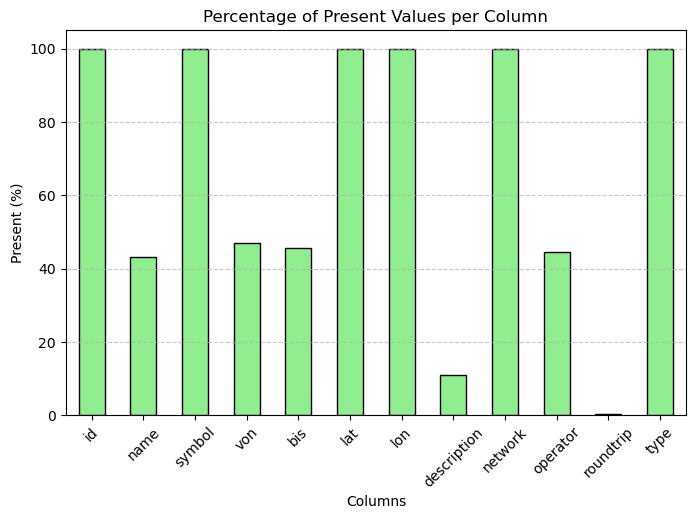

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the percentage of present (non-null) values for each column
present_percentage = df_wanderwege.notnull().mean() * 100

# Create bar chart
plt.figure(figsize=(8, 5))
present_percentage.plot(kind='bar', color='lightgreen', edgecolor='black')

# Add chart labels and title
plt.title("Percentage of Present Values per Column")
plt.ylabel("Present (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)  # Slight tilt for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()

### Interpollation of missing names

In [ ]:

# Counter for constructed names
constructed_count = 0

# Iterate over rows and construct names if missing
for index, row in df_wanderwege.iterrows():
    # Original values
    org_name = row["name"]
    org_from = row["von"]
    org_to = row["bis"]
    
    # Construct name if missing and 'von' and 'bis' are available
    if pd.isnull(org_name) and pd.notnull(org_from) and pd.notnull(org_to):
        df_wanderwege.at[index, "name"] = f"{org_from} - {org_to}"
        constructed_count += 1  # Increment counter

# Print the count of constructed names
print(f"Number of names constructed: {constructed_count}")

# Drop rows with missing 'name'
df_wanderwege = df_wanderwege.dropna(subset=["name"])

Number of names constructed: 7896


### Identifying duplicate rows


In [ ]:
# Find duplicate rows where all attributes are identical
duplicate_count = df_wanderwege.duplicated().sum()

# Print the result
print(f"Number of duplicate rows: {duplicate_count}")

Number of fully duplicate rows: 0


### Identifying similar rows

In [34]:
from rapidfuzz import fuzz, process
import pandas as pd

# Namen auf Ähnlichkeit prüfen
threshold = 80  # Ähnlichkeitsschwelle (z. B. 80%)
similar_names = []

# Iteriere über alle Namen
for index, name in enumerate(df_wanderwege["name"]):
    for other_index, other_name in enumerate(df_wanderwege["name"]):
        if index != other_index:  # Nicht mit sich selbst vergleichen
            score = fuzz.ratio(name, other_name)
            if score >= threshold:  # Wenn Ähnlichkeit über Schwelle liegt
                similar_names.append((name, other_name, score))

# Ähnliche Namen anzeigen
print("Ähnliche Namen:")
for name1, name2, score in similar_names:
    print(f"'{name1}' und '{name2}' haben eine Ähnlichkeit von {score}%.")


Ähnliche Namen:
'Nationalpark Wanderroute 15 (Munt la Schera)' und 'Nationalpark Wanderroute 16 (Fuorntal)' haben eine Ähnlichkeit von 80.48780487804879%.
'Wanderwege SG' und 'Wanderweg' haben eine Ähnlichkeit von 81.81818181818181%.
'Wanderwege SG' und 'Wanderweg' haben eine Ähnlichkeit von 81.81818181818181%.
'Wanderwege SG' und 'Wanderweg' haben eine Ähnlichkeit von 81.81818181818181%.
'Uetliberg - Uetliberg Uto Kulm' und 'Albisgüetli - Uetliberg Uto Kulm' haben eine Ähnlichkeit von 80.64516129032258%.
'Uetliberg - Uetliberg Uto Kulm' und 'Sellenbüren - Uetliberg Uto Kulm' haben eine Ähnlichkeit von 80.64516129032258%.
'Les Illars-Les Cernets Dessus' und 'Les Illars-Les Cernets-Dessous' haben eine Ähnlichkeit von 94.91525423728814%.
'Untere Alpli - Obere Alpli' und 'Alpli - Ober Alpli' haben eine Ähnlichkeit von 81.81818181818181%.
'Untere Alpli - Obere Alpli' und 'Unter Alpli - Alpli' haben eine Ähnlichkeit von 84.44444444444444%.
'Hohenstein - Uetliberg Uto Kulm' und 'Hohenstein -

In [124]:
print(f"Anzahl der Zeilen im DataFrame: {df_wanderwege.shape[0]}")


Anzahl der Zeilen im DataFrame: 2824


### Remove similar Names

In [123]:
threshold = 80

# List of indices to drop
indices_to_drop = set()

# Iterate over all names
for index, name in enumerate(df_wanderwege["name"]):
    if index not in indices_to_drop: 
        matches = process.extract(
            name, df_wanderwege["name"], scorer=fuzz.ratio, limit=len(df_wanderwege)
        )
        # Iterate over all matches
        for match_name, score, match_index in matches:
            if score >= threshold and index != match_index:
                indices_to_drop.add(match_index)

# Drop the indices
df_wanderwege = df_wanderwege.drop(indices_to_drop)

In [121]:
df_wanderwege = df_wanderwege[~df_wanderwege["name"].str.contains("fixme", case=False, na=False)]

### Analyze latitude and loninude

In [ ]:
# DataFrame für die relevanten Spalten vorbereiten
df_melted = df_wanderwege[["lat", "lon"]].melt(var_name="Variable", value_name="Wert")

# Boxplot zeichnen
plt.figure(figsize=(8, 6))
sns.boxplot(x="Variable", y="Wert", data=df_melted)
plt.title("Boxplot der Verteilung von Latitude und Longitude")
plt.ylabel("Wert")
plt.xlabel("Variable")
plt.show()


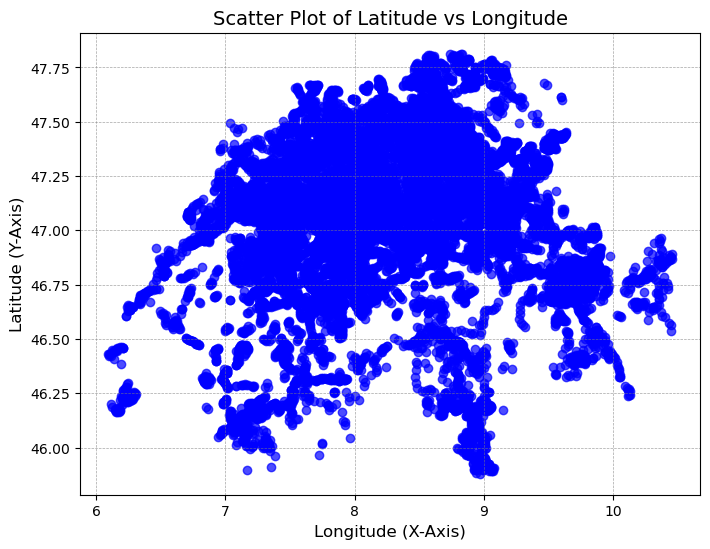

In [42]:
# Create a scatter plot
plt.figure(figsize=(8, 6))  # Set figure size
plt.scatter(df_wanderwege['lon'], df_wanderwege['lat'], color='blue', alpha=0.7)

# Add labels and title
plt.title("Scatter Plot of Latitude vs Longitude", fontsize=14)
plt.xlabel("Longitude (X-Axis)", fontsize=12)
plt.ylabel("Latitude (Y-Axis)", fontsize=12)


# Show grid and plot
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

### Remove invalid latitude and longitude

In [41]:
# Prüfen und Entfernen von Zeilen mit negativen Werten in 'lan' und 'lot'
df_wanderwege = df_wanderwege[(df_wanderwege["lat"] > 0) & (df_wanderwege["lon"] > 0)]

# Ergebnis anzeigen
print(df_wanderwege)


             id                                          name  \
0         22614  Nationalpark Wanderroute 15 (Munt la Schera)   
1        103607                                 Wanderwege SG   
2        112830                                          None   
3        112831                                          None   
4        112833                                          None   
...         ...                                           ...   
19668  18317856          Vor Ebringen - Rosselebuck Ob Tunnel   
19669  18321013                       Schlatter Weg - Waldhof   
19670  18321014     Mühlhausen Johannisbrücke - Schlatter Weg   
19672  18321366                                          None   
19673  18321367                                          None   

                            symbol        von                 bis        lat  \
0                red:white:red_bar       None                None  46.650143   
1           yellow::yellow_diamond       None              

### optional: Store data in csv


In [113]:
df_wanderwege.to_csv("../data/processed/overpass.csv")

### Connect to SQL Server

In [114]:
# Load configuration from config/db_config.json
with open('../config/db_config.json', 'r') as f:
    db_config = json.load(f)

# Get database credentials
server = db_config['server']
database = db_config['database']
db_user = db_config['db_user']
db_password = db_config['db_password']

### Create empty SQL table

In [115]:
# Create table if it doesn't exist
table_name = "OVRP_HikingRoutes"
query = f"""
    IF OBJECT_ID(N'dbo.{table_name}', N'U') IS NULL
    BEGIN
        CREATE TABLE {table_name} (
            id                      INT         NOT NULL,
            name                    VARCHAR(255) NULL,
            von                     VARCHAR(255) NULL,
            bis                     VARCHAR(255) NULL,
            lat                     FLOAT       NOT NULL,
            lon                     FLOAT       NOT NULL,
            symbol                  VARCHAR(255) NULL,
            timestamp_apicall       DATETIME    NULL,
            PRIMARY KEY (id)
        );
    END
    """

conn = pymssql.connect(server, db_user, db_password, database)
cursor = conn.cursor()
cursor.execute(query)

conn.commit()
conn.close()

### Upload to SQL Server

In [125]:
# Create connection string for SQLAlchemy
connection_string = f"mssql+pymssql://{db_user}:{db_password}@{server}/{database}"
engine = create_engine(connection_string)

# Ingest data to tabledatabase table
df_wanderwege.to_sql(table_name, con=engine, if_exists='replace', index=False)
print("DataFrame erfolgreich in die MSSQL-Datenbank geladen!")

DataFrame erfolgreich in die MSSQL-Datenbank geladen!
